In [1]:
path = '/home/user/Desktop/diploma'

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

In [ ]:
sys.path.append(os.path.abspath(path+'/eraserbenchmark-master'))
from rationale_benchmark.utils import annotations_from_jsonl

In [21]:
plt.style.use('default')
sns.set_palette("husl")

class ModelAnalyzer:
    def __init__(self, base_path):
        self.base_path = base_path
        self.results = {}

    def analyze_dataset(self, dataset_name, models, attack_suffix="TextFoolerJin2019.csv"):
        """Analyze a dataset for multiple models"""
        print(f"\n{'='*50}")
        print(f"Analyzing {dataset_name.upper()} dataset")
        print(f"{'='*50}")

        # Load dataset specific data
        if dataset_name == 'movies':
            data_root = os.path.join(self.base_path, 'eraserbenchmark-master/data/movies')
            annotations = annotations_from_jsonl(os.path.join(data_root, 'test.jsonl'))
            def label_mapping(x):
                return 'negative' if x.annotation_id[0] == 'n' else 'positive'

        elif dataset_name == 'esnli':
            data_root = os.path.join(self.base_path, 'eraserbenchmark-master/data/esnli')
            annotations = annotations_from_jsonl(os.path.join(data_root, 'test.jsonl'))
            annotations = [inst for inst in annotations if inst.classification in ('entailment', 'contradiction')]
            def label_mapping(x):
                return 'no' if x.classification == 'contradiction' else 'yes'

        dataset_results = {}

        for model in models:
            print(f"\nAnalyzing {model}...")
            cf_file = f"analysis_m-{model}_y-none_d-{'imdb' if dataset_name == 'movies' else 'rte'}_p-test_t-counterfactual_c-_s-0.sqlite"
            cf_path = os.path.join(self.base_path, "introspections/results/analysis")

            conn = sqlite3.connect(os.path.join(cf_path, cf_file))
            df = pd.read_sql_query("SELECT * FROM Counterfactual", conn)
            conn.close()

            # Load attack data
            attack_path = os.path.join(self.base_path, f'attacks/{ "movie" if dataset_name == "movies" else "esnli" }_attacks')
            attack_df = pd.read_csv(os.path.join(attack_path, f"{model}_{attack_suffix}"))

            # Calculate metrics
            metrics = self._calculate_metrics(df, attack_df, annotations, label_mapping)
            dataset_results[model] = metrics

            print(f"  Self Accuracy: {metrics['self_accuracy']:.3f}")
            print(f"  Attack Accuracy: {metrics['attack_accuracy']:.3f}")
            print(f"  Alignment: {metrics['alignment']:.3f}")

        self.results[dataset_name] = dataset_results
        return dataset_results

    def _calculate_metrics(self, cf_df, attack_df, annotations, label_mapping):
        """Calculate performance metrics"""
        aligned = 0
        attack_correct = 0
        self_correct = 0
        total = min(len(cf_df), len(attack_df), len(annotations))

        for i in range(total):
            true_label = label_mapping(annotations[i])

            # Attack accuracy
            if (attack_df.iloc[i]['original_output'] < 0.5 and true_label == 'negative') or \
               (attack_df.iloc[i]['original_output'] > 0.5 and true_label == 'positive') or \
               (attack_df.iloc[i]['original_output'] < 0.5 and true_label == 'no') or \
               (attack_df.iloc[i]['original_output'] > 0.5 and true_label == 'yes'):
                attack_correct += 1

            # Self accuracy
            if cf_df.iloc[i]['predict'] == true_label:
                self_correct += 1

            # Alignment
            if (attack_df.iloc[i]['original_output'] < 0.5 and cf_df.iloc[i]['predict'] == 'negative') or \
               (attack_df.iloc[i]['original_output'] > 0.5 and cf_df.iloc[i]['predict'] == 'positive') or \
               (attack_df.iloc[i]['original_output'] < 0.5 and cf_df.iloc[i]['predict'] == 'no') or \
               (attack_df.iloc[i]['original_output'] > 0.5 and cf_df.iloc[i]['predict'] == 'yes'):
                aligned += 1

        return {
            'self_accuracy': self_correct / total,
            'attack_accuracy': attack_correct / total,
            'alignment': aligned / total,
            'total_samples': total
        }

    def plot_accuracy_vs_size(self, save_path=None):
        """Plot accuracy vs model size for both datasets"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle('Accuracy vs Model Size', fontsize=16, fontweight='bold')

        # Model size mapping
        size_mapping = {
            '1b': 1.0, '3b': 3.0,
            '7b': 7.0, '8b': 8.0
        }

        # Plot for Movies dataset
        movies_results = self.results.get('movies', {})

        # Llama models for movies
        llama_sizes = []
        llama_accuracies = []

        for model, metrics in movies_results.items():
            if 'llama' in model:
                for key, size in size_mapping.items():
                    if key in model:
                        llama_sizes.append(size)
                        llama_accuracies.append(metrics['self_accuracy'])
                        break

        if llama_sizes:
            sorted_data = sorted(zip(llama_sizes, llama_accuracies))
            sizes, accuracies = zip(*sorted_data)
            ax1.plot(sizes, accuracies, 'o-', linewidth=3, markersize=10,
                    label='Llama', color='skyblue', markerfacecolor='blue', markeredgecolor='black')

        # Qwen models for movies
        qwen_sizes = []
        qwen_accuracies = []

        for model, metrics in movies_results.items():
            if 'qwen' in model:
                for key, size in size_mapping.items():
                    if key in model:
                        if size == 1.0:
                            size = 1.5  
                        qwen_sizes.append(size)
                        qwen_accuracies.append(metrics['self_accuracy'])
                        break

        if qwen_sizes:
            sorted_data = sorted(zip(qwen_sizes, qwen_accuracies))
            sizes, accuracies = zip(*sorted_data)
            ax1.plot(sizes, accuracies, 's-', linewidth=3, markersize=10,
                    label='Qwen', color='lightcoral', markerfacecolor='red', markeredgecolor='black')

        ax1.set_title('Movies Dataset', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Model Size (Billion Parameters)', fontsize=12)
        ax1.set_ylabel('Accuracy', fontsize=12)
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=11)
        ax1.set_ylim(0, 1)

        # Plot for e-SNLI dataset
        esnli_results = self.results.get('esnli', {})

        # Llama models for e-SNLI
        llama_sizes = []
        llama_accuracies = []

        for model, metrics in esnli_results.items():
            if 'llama' in model:
                for key, size in size_mapping.items():
                    if key in model:
                        llama_sizes.append(size)
                        llama_accuracies.append(metrics['self_accuracy'])
                        break

        if llama_sizes:
            sorted_data = sorted(zip(llama_sizes, llama_accuracies))
            sizes, accuracies = zip(*sorted_data)
            ax2.plot(sizes, accuracies, 'o-', linewidth=3, markersize=10,
                    label='Llama', color='skyblue', markerfacecolor='blue', markeredgecolor='black')

        # Qwen models for e-SNLI
        qwen_sizes = []
        qwen_accuracies = []

        for model, metrics in esnli_results.items():
            if 'qwen' in model:
                for key, size in size_mapping.items():
                    if key in model:
                        if size == 1.0:
                            size = 1.5  
                        qwen_sizes.append(size)
                        qwen_accuracies.append(metrics['self_accuracy'])
                        break

        if qwen_sizes:
            sorted_data = sorted(zip(qwen_sizes, qwen_accuracies))
            sizes, accuracies = zip(*sorted_data)
            ax2.plot(sizes, accuracies, 's-', linewidth=3, markersize=10,
                    label='Qwen', color='lightcoral', markerfacecolor='red', markeredgecolor='black')

        ax2.set_title('e-SNLI Dataset', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Model Size (Billion Parameters)', fontsize=12)
        ax2.set_ylabel('Accuracy', fontsize=12)
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=11)
        ax2.set_ylim(0, 1)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Self accuracy plot saved to {save_path}")

        plt.show()

    def generate_summary_table(self):
        """Generate a summary table of all results"""
        summary_data = []

        for dataset_name, dataset_results in self.results.items():
            for model, metrics in dataset_results.items():
                summary_data.append({
                    'Dataset': dataset_name.upper(),
                    'Model': model,
                    'Self Accuracy': f"{metrics['self_accuracy']:.3f}",
                    'Attack Accuracy': f"{metrics['attack_accuracy']:.3f}",
                    'Alignment': f"{metrics['alignment']:.3f}",
                    'Samples': metrics['total_samples']
                })

        summary_df = pd.DataFrame(summary_data)
        return summary_df

In [ ]:
analyzer = ModelAnalyzer(path)

# Define models
llama_models = ['llama3-1b', 'llama3-3b', 'llama3-8b']
qwen_models = ['qwen-1b', 'qwen-3b', 'qwen-7b']

all_models = llama_models + qwen_models

# Analyze datasets
analyzer.analyze_dataset('movies', all_models)
analyzer.analyze_dataset('esnli', all_models)


Analyzing MOVIES dataset

Analyzing llama3-1b...
  Self Accuracy: 0.533
  Attack Accuracy: 0.799
  Alignment: 0.492

Analyzing llama3-3b...
  Self Accuracy: 0.905
  Attack Accuracy: 0.935
  Alignment: 0.960

Analyzing llama3-8b...
  Self Accuracy: 0.975
  Attack Accuracy: 0.970
  Alignment: 0.985

Analyzing qwen-1b...
  Self Accuracy: 0.905
  Attack Accuracy: 0.960
  Alignment: 0.945

Analyzing qwen-3b...
  Self Accuracy: 0.854
  Attack Accuracy: 0.869
  Alignment: 0.965

Analyzing qwen-7b...
  Self Accuracy: 0.945
  Attack Accuracy: 0.945
  Alignment: 1.000

Analyzing ESNLI dataset

Analyzing llama3-1b...
  Self Accuracy: 0.650
  Attack Accuracy: 0.606
  Alignment: 0.638

Analyzing llama3-3b...
  Self Accuracy: 0.713
  Attack Accuracy: 0.731
  Alignment: 0.888

Analyzing llama3-8b...
  Self Accuracy: 0.851
  Attack Accuracy: 0.884
  Alignment: 0.923

Analyzing qwen-1b...
  Self Accuracy: 0.923
  Attack Accuracy: 0.900
  Alignment: 0.922

Analyzing qwen-3b...
  Self Accuracy: 0.792
  

{'llama3-1b': {'self_accuracy': 0.6495907850863898,
  'attack_accuracy': 0.6056380721430736,
  'alignment': 0.6383752652318885,
  'total_samples': 6598},
 'llama3-3b': {'self_accuracy': 0.7132464383146409,
  'attack_accuracy': 0.7306759624128524,
  'alignment': 0.8879963625341012,
  'total_samples': 6598},
 'llama3-8b': {'self_accuracy': 0.8505607759927251,
  'attack_accuracy': 0.8837526523188846,
  'alignment': 0.9225522885722947,
  'total_samples': 6598},
 'qwen-1b': {'self_accuracy': 0.9230069718096393,
  'attack_accuracy': 0.8995150045468324,
  'alignment': 0.9219460442558352,
  'total_samples': 6598},
 'qwen-3b': {'self_accuracy': 0.7923613216126099,
  'attack_accuracy': 0.654440739618066,
  'alignment': 0.8016065474386178,
  'total_samples': 6598},
 'qwen-7b': {'self_accuracy': 0.9333131251894513,
  'attack_accuracy': 0.937708396483783,
  'alignment': 0.975295544104274,
  'total_samples': 6598}}

Self accuracy plot saved to /home/user/Desktop/diploma/results/classifiers_accuracy_vs_size.png


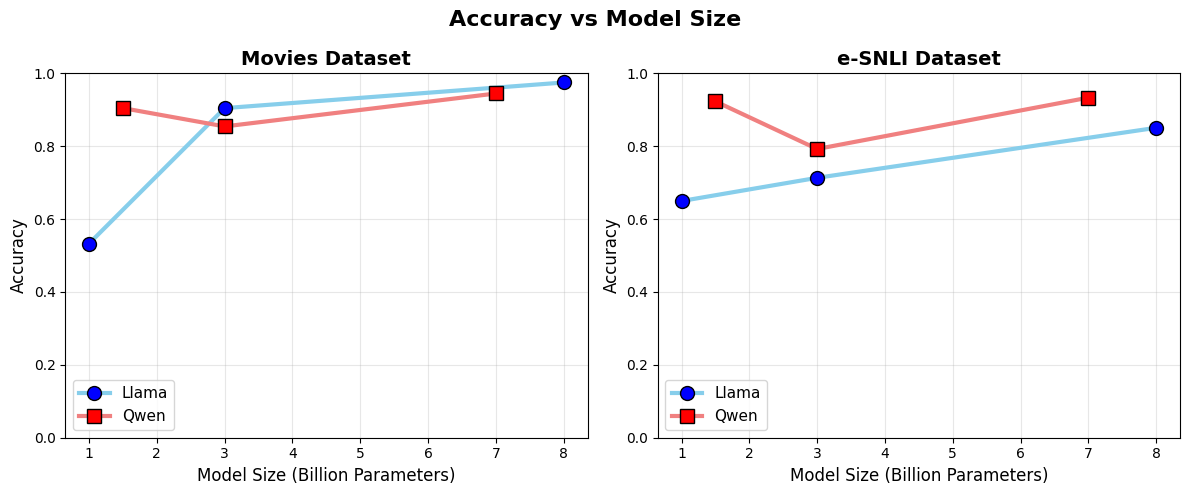


COMPREHENSIVE RESULTS SUMMARY
Dataset     Model Self Accuracy Attack Accuracy Alignment  Samples
 MOVIES llama3-1b         0.533           0.799     0.492      199
 MOVIES llama3-3b         0.905           0.935     0.960      199
 MOVIES llama3-8b         0.975           0.970     0.985      199
 MOVIES   qwen-1b         0.905           0.960     0.945      199
 MOVIES   qwen-3b         0.854           0.869     0.965      199
 MOVIES   qwen-7b         0.945           0.945     1.000      199
  ESNLI llama3-1b         0.650           0.606     0.638     6598
  ESNLI llama3-3b         0.713           0.731     0.888     6598
  ESNLI llama3-8b         0.851           0.884     0.923     6598
  ESNLI   qwen-1b         0.923           0.900     0.922     6598
  ESNLI   qwen-3b         0.792           0.654     0.802     6598
  ESNLI   qwen-7b         0.933           0.938     0.975     6598


In [23]:
# Generate self accuracy vs size plot
analyzer.plot_accuracy_vs_size(save_path=path+'/results/classifiers_accuracy_vs_size.png')

# Generate summary table (for alignment information)
summary_df = analyzer.generate_summary_table()
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))